In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ecg-data/mitbih_test.csv
/kaggle/input/ecg-data/mitbih_train.csv
/kaggle/input/ecg-model/tensorflow2/default/1/ecg_attention_extractor.h5


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer
from sklearn.model_selection import train_test_split


2026-03-07 10:09:12.850372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772878153.035266      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772878153.086383      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772878153.520158      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772878153.520197      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772878153.520200      23 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv("/kaggle/input/ecg-data/mitbih_train.csv", header=None)

X = df.iloc[:, :-1].values   # (N, 187)
y = df.iloc[:, -1].values


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [5]:
def moving_average(signal, window=5):
    return np.convolve(signal, np.ones(window) / window, mode="same")

def create_ts_channels(signal):
    original = signal
    smooth = moving_average(signal)
    derivative = np.gradient(signal)

    def norm(x):
        return (x - np.mean(x)) / (np.std(x) + 1e-8)

    return np.stack([
        norm(original),
        norm(smooth),
        norm(derivative)
    ], axis=1)

X_val_ts = np.array([create_ts_channels(x) for x in X_val])
print(X_val_ts.shape)   # (samples, 187, 3)


(17511, 187, 3)


In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )

    def call(self, x):
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = tf.reduce_sum(x * a, axis=1)
        return output, a

    def get_config(self):
        config = super().get_config()
        return config


In [7]:
model = load_model(
    "/kaggle/input/ecg-model/tensorflow2/default/1/ecg_attention_extractor.h5",  # adjust path if needed
    custom_objects={"TemporalAttention": TemporalAttention}
)

model.trainable = False
model.summary()



I0000 00:00:1772878175.003873      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 187, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 187, 128)       │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 187, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 128), (None,   │           315 │
│ (TemporalAttention)             │ 187, 1)]               │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,947 (523.23 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 133,947 (523.23 KB)

In [8]:
idx = 10
x_sample = tf.convert_to_tensor(
    X_val_ts[idx:idx+1], dtype=tf.float32
)


## Attention Visualization (Timestamps emphasized)

In [9]:
from tensorflow.keras.models import Model

# Get the attention layer by name
att_layer = model.get_layer('temporal_attention')

# Create a new model from input to the attention layer
att_model = Model(inputs=model.input, outputs=att_layer.output)

# Get both outputs (context and attention)
context_vec, attention = att_model(x_sample, training=False)
attention = attention.numpy().squeeze()




I0000 00:00:1772878176.609008      65 cuda_dnn.cc:529] Loaded cuDNN version 91002


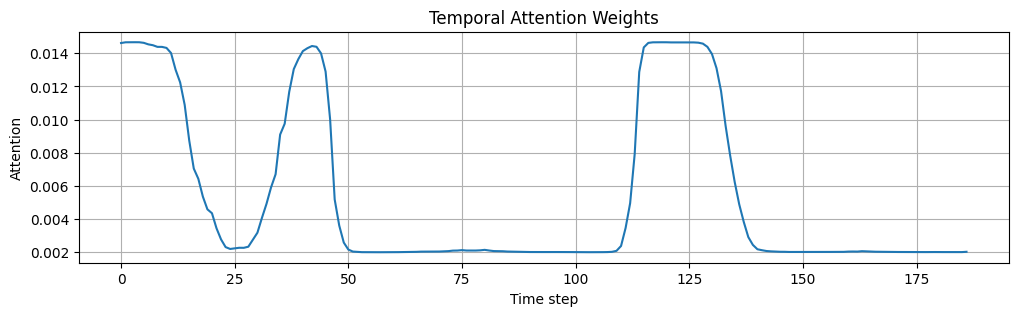

In [10]:
plt.figure(figsize=(12,3))
plt.plot(attention)
plt.title("Temporal Attention Weights")
plt.xlabel("Time step")
plt.ylabel("Attention")
plt.grid()
plt.savefig("temporal_attention_weights.png", dpi=300, bbox_inches="tight")
plt.show()


## SALIENCY OF ATTENTION

In [11]:
pred = model(x_sample)
target_class = int(tf.argmax(pred[0]))

with tf.GradientTape() as tape:
    tape.watch(x_sample)
    pred = model(x_sample)
    loss = pred[:, target_class]

grads = tape.gradient(loss, x_sample)[0]

saliency = tf.abs(grads)
saliency_time = tf.reduce_mean(saliency, axis=1).numpy()
saliency_norm = saliency_time / (saliency_time.max() + 1e-8)

In [12]:
def smoothgrad(model, x, target_class, samples=30, noise_std=0.02):

    grads = []

    for _ in range(samples):

        noise = tf.random.normal(x.shape, stddev=noise_std)
        x_noisy = x + noise

        with tf.GradientTape() as tape:
            tape.watch(x_noisy)

            pred = model(x_noisy)
            loss = pred[:, target_class]

        grad = tape.gradient(loss, x_noisy)

        grads.append(tf.abs(grad))

    grads = tf.reduce_mean(tf.stack(grads), axis=0)

    return grads

In [13]:
saliency = smoothgrad(model, x_sample, target_class)

saliency_time = tf.reduce_mean(saliency[0], axis=1).numpy()
saliency_norm = saliency_time / (saliency_time.max()+1e-8)

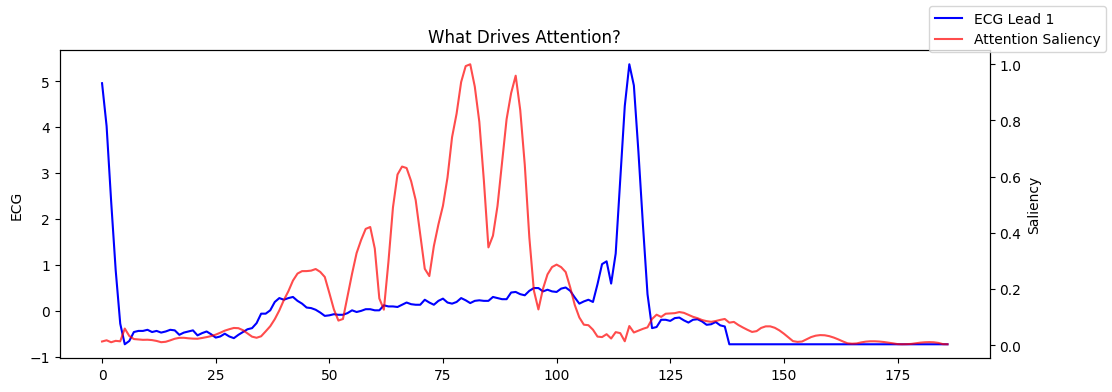

In [14]:
time = np.arange(187)
fig, ax1 = plt.subplots(figsize=(12,4))

ax1.plot(time, x_sample[0,:,0], color="blue", label="ECG Lead 1")
ax1.set_ylabel("ECG")

ax2 = ax1.twinx()
ax2.plot(time, saliency_norm, color="red", alpha=0.7, label="Attention Saliency")
ax2.set_ylabel("Saliency")

fig.legend(loc="upper right")
plt.title("What Drives Attention?")
plt.savefig("attention_saliency.png", dpi=300, bbox_inches="tight")
plt.show()


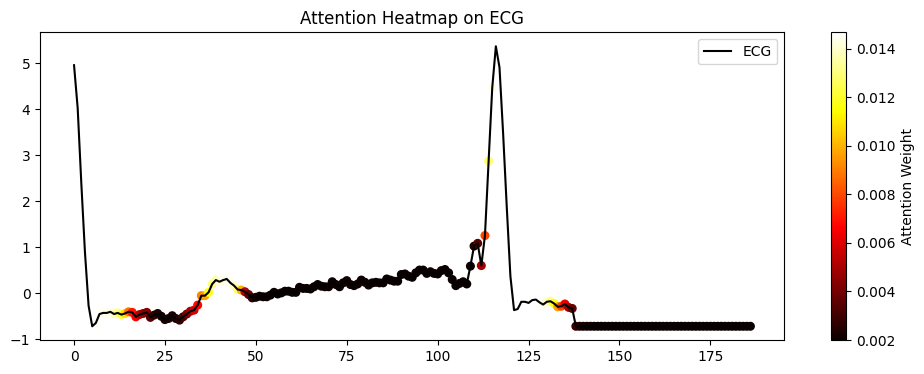

In [15]:
plt.figure(figsize=(12,4))

plt.plot(x_sample[0,:,0], color="black", label="ECG")

plt.scatter(
    np.arange(187),
    x_sample[0,:,0],
    c=attention,
    cmap="hot",
    s=30
)

plt.colorbar(label="Attention Weight")

plt.title("Attention Heatmap on ECG")

plt.legend()

plt.show()

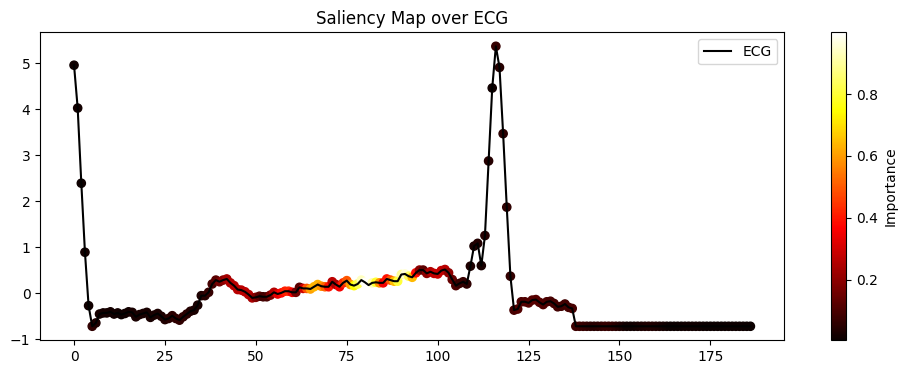

In [16]:
plt.figure(figsize=(12,4))

plt.plot(x_sample[0,:,0], color="black", label="ECG")

plt.scatter(
    np.arange(187),
    x_sample[0,:,0],
    c=saliency_norm,
    cmap="hot",
    s=35
)

plt.colorbar(label="Importance")

plt.title("Saliency Map over ECG")

plt.legend()

plt.show()

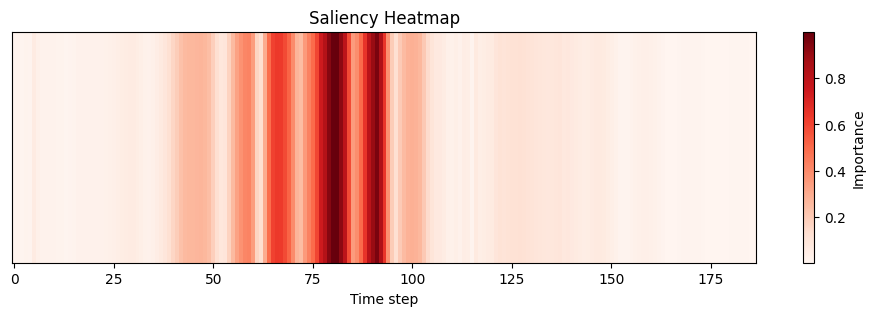

In [17]:
plt.figure(figsize=(12,3))

plt.imshow(
    saliency_norm[np.newaxis,:],
    aspect="auto",
    cmap="Reds"
)

plt.yticks([])
plt.xlabel("Time step")

plt.title("Saliency Heatmap")

plt.colorbar(label="Importance")

plt.show()

## Attention Stability (Does attention change under noise?)

In [18]:
noise_std = 0.05
x_noisy = x_sample + tf.random.normal(x_sample.shape, stddev=noise_std)

_, att_clean = att_model(x_sample, training=False)   # ✅ use att_model
_, att_noisy = att_model(x_noisy, training=False)

att_clean = att_clean.numpy().squeeze()
att_noisy = att_noisy.numpy().squeeze()




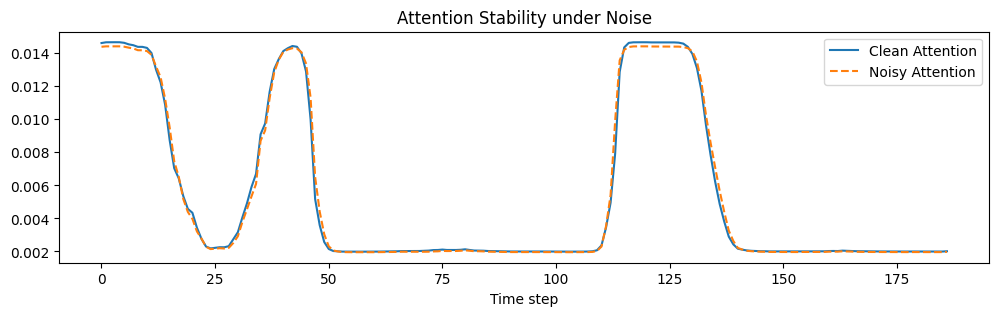

In [19]:
plt.figure(figsize=(12,3))
plt.plot(att_clean, label="Clean Attention")
plt.plot(att_noisy, label="Noisy Attention", linestyle="--")
plt.legend()
plt.title("Attention Stability under Noise")
plt.xlabel("Time step")
plt.savefig("attention_stability.png", dpi=300, bbox_inches="tight")
plt.show()


## Integrated Gradients on Attention

In [20]:
baseline = tf.zeros_like(x_sample)
steps = 50

alphas = tf.linspace(0.0, 1.0, steps)
ig = tf.zeros_like(x_sample)

for alpha in alphas:
    x_interp = baseline + alpha * (x_sample - baseline)

    with tf.GradientTape() as tape:
        tape.watch(x_interp)
        _, attention = att_model(x_interp, training=False)  # ✅ use att_model
        att_sum = tf.reduce_sum(attention)

    grads = tape.gradient(att_sum, x_interp)
    ig += grads

ig = ig / steps * (x_sample - baseline)
ig_time = tf.reduce_mean(tf.abs(ig[0]), axis=1).numpy()
ig_norm = ig_time / (ig_time.max() + 1e-8)



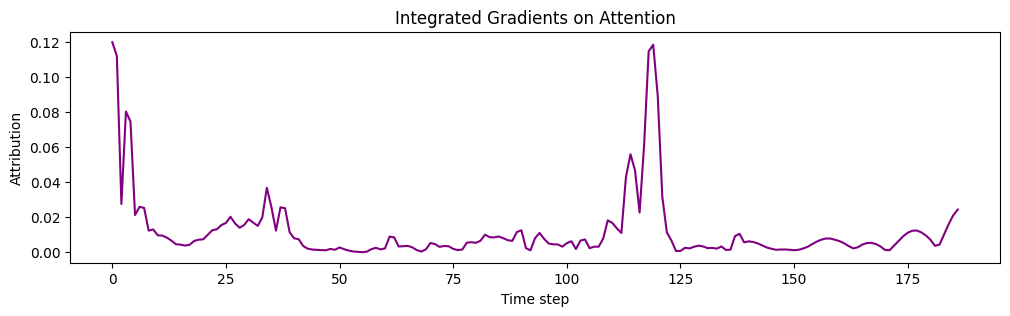

In [21]:
plt.figure(figsize=(12,3))
plt.plot(ig_norm, color="purple")
plt.title("Integrated Gradients on Attention")
plt.xlabel("Time step")
plt.ylabel("Attribution")
plt.savefig("integrated_gradients_attention.png", dpi=300, bbox_inches="tight")
plt.show()


In [22]:
from sklearn.metrics import auc

def deletion_curve(model, x_sample, saliency, steps=30):

    x = x_sample.numpy().copy()
    sal = saliency.copy()

    order = np.argsort(-sal)  # most important first
    scores = []

    for i in range(steps):

        frac = int(len(order) * i / steps)
        window = 5
        idx = []

        for p in order[:frac]:
            idx.extend(range(max(0,p-window), min(187,p+window)))

        x_masked = x.copy()
        mean_val = np.mean(x)
        x_masked[0, idx, :] = mean_val

        pred = model(x_masked)
        score = pred[0, target_class].numpy()

        scores.append(score)

    return scores

In [23]:
from scipy.ndimage import gaussian_filter1d

saliency_norm = gaussian_filter1d(saliency_norm, sigma=2)
saliency_for_eval = gaussian_filter1d(saliency_time, sigma=2)
saliency_for_eval = saliency_for_eval / (saliency_for_eval.sum() + 1e-8)

In [24]:
del_scores = deletion_curve(model, x_sample, saliency_for_eval)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 187, 3))
  warnings.warn(msg)


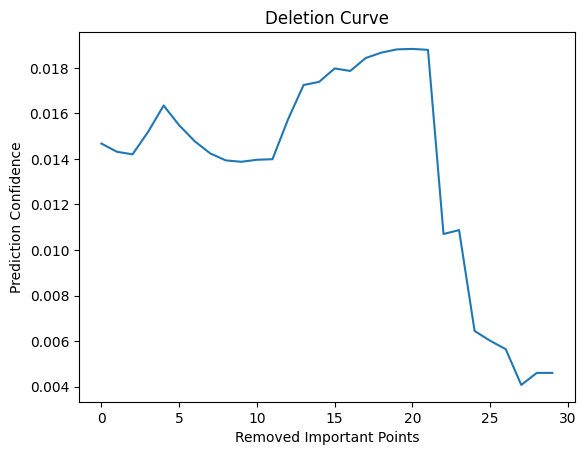

In [25]:
plt.plot(del_scores)
plt.title("Deletion Curve")
plt.xlabel("Removed Important Points")
plt.ylabel("Prediction Confidence")
plt.show()

In [26]:
def insertion_curve(model, x_sample, saliency, target_class, steps=30):

    x = x_sample.numpy()

    baseline = np.ones_like(x) * np.mean(x)

    order = np.argsort(-saliency)

    x_insert = baseline.copy()

    scores = []

    for i in range(steps):

        frac = int(len(order) * i / steps)

        window = 5
        idx = []

        for p in order[:frac]:
            idx.extend(range(max(0, p-window), min(187, p+window)))

        x_insert[0, idx, :] = x[0, idx, :]

        pred = model(x_insert)

        score = pred[0, target_class].numpy()

        scores.append(score)

    return scores

In [27]:
from sklearn.metrics import auc

x = np.arange(len(del_scores))

deletion_auc = auc(x, del_scores)
print("Deletion AUC:", deletion_auc)

Deletion AUC: 0.3980222


In [28]:
insert_scores = insertion_curve(
    model,
    x_sample,
    saliency_for_eval,
    target_class,
    steps=30
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 187, 3))
  warnings.warn(msg)


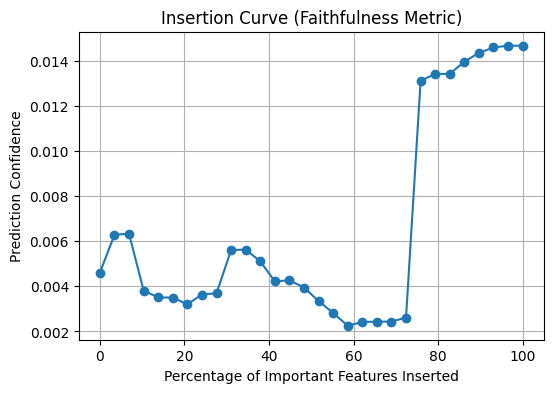

In [29]:
import matplotlib.pyplot as plt

x_axis = np.linspace(0,100,len(insert_scores))

plt.figure(figsize=(6,4))

plt.plot(x_axis, insert_scores, marker='o')

plt.xlabel("Percentage of Important Features Inserted")
plt.ylabel("Prediction Confidence")
plt.title("Insertion Curve (Faithfulness Metric)")

plt.grid()

plt.savefig("insertion_curve.png", dpi=300, bbox_inches="tight")

plt.show()

In [30]:
from sklearn.metrics import auc

x = np.arange(len(insert_scores))

insertion_auc = auc(x, insert_scores)

print("Insertion AUC:", insertion_auc)

Insertion AUC: 0.18823633


In [31]:
from scipy.signal import find_peaks

signal = x_sample[0,:,0].numpy()

peaks,_ = find_peaks(
    signal,
    distance=25,
    prominence=0.3
)

r_peak = peaks[np.argmax(signal[peaks])]

In [32]:

saliency_peak = np.argmax(saliency_norm)

localization_error = abs(saliency_peak - r_peak)

print("Peak localization error:", localization_error)

Peak localization error: 36


In [33]:
k = 50
top_idx = np.argsort(-saliency_norm)[:k]

att_mask = np.zeros_like(saliency_norm, dtype=bool)
att_mask[top_idx] = True


In [34]:
r_mask = np.zeros_like(att_mask)

window = 25

for p in peaks:
    start = max(0, p-window)
    end = min(187, p+window)
    r_mask[start:end] = True

In [35]:
intersection = np.sum(att_mask & r_mask)
union = np.sum(att_mask | r_mask)

iou = intersection / (union + 1e-8)

print("IoU:", iou)

IoU: 0.20967741933792924


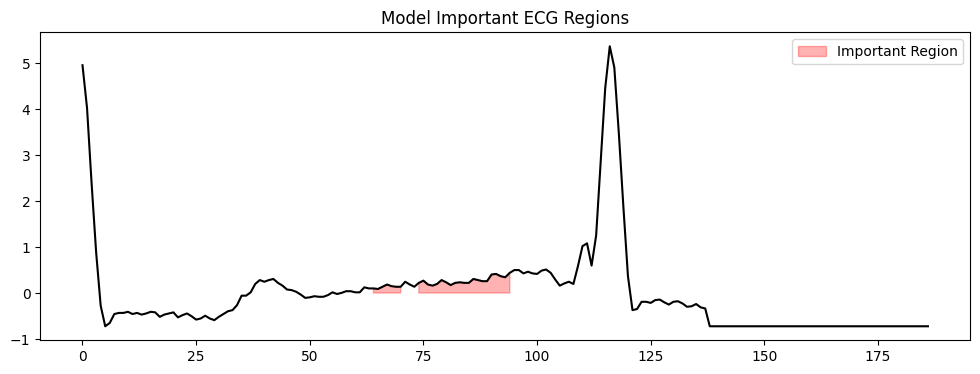

In [36]:
plt.figure(figsize=(12,4))

plt.plot(signal, color='black')

plt.fill_between(
    np.arange(187),
    signal,
    where=(saliency_norm > np.percentile(saliency_norm,85)),
    color='red',
    alpha=0.3,
    label="Important Region"
)

plt.legend()
plt.title("Model Important ECG Regions")

plt.show()

In [37]:
from scipy.stats import spearmanr

corr, _ = spearmanr(att_clean, att_noisy)

print("Spearman correlation:", corr)

Spearman correlation: 0.9962177795558231


In [38]:
def integrated_gradients(model, x, baseline, target_class, steps=50):

    alphas = tf.linspace(0.0, 1.0, steps+1)

    integrated_grads = tf.zeros_like(x)

    for alpha in alphas:

        x_interp = baseline + alpha * (x - baseline)

        with tf.GradientTape() as tape:
            tape.watch(x_interp)

            preds = model(x_interp, training=False)

            loss = preds[:, int(target_class)]

        grads = tape.gradient(loss, x_interp)

        integrated_grads += grads

    integrated_grads /= tf.cast(steps + 1, tf.float32)

    integrated_grads *= (x - baseline)

    return integrated_grads

In [39]:
x_noisy = x_sample + tf.random.normal(x_sample.shape, stddev=0.05)

preds_noisy = model(x_noisy, training=False)

target_class_noisy = int(tf.argmax(preds_noisy[0]))

ig_noisy = integrated_gradients(
    model=model,
    x=x_noisy,
    baseline=baseline,
    target_class=target_class_noisy,
    steps=50
)

ig_abs_noisy = tf.abs(ig_noisy)[0]

ig_time_noisy = tf.reduce_mean(ig_abs_noisy, axis=1).numpy()

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

ig1 = ig_time
ig2 = ig_time_noisy

ig1 = ig1 / (np.linalg.norm(ig1) + 1e-8)
ig2 = ig2 / (np.linalg.norm(ig2) + 1e-8)

sim = cosine_similarity(
    ig1.reshape(1,-1),
    ig2.reshape(1,-1)
)[0][0]

print("IG Cosine Similarity:", sim)

IG Cosine Similarity: 0.7677737


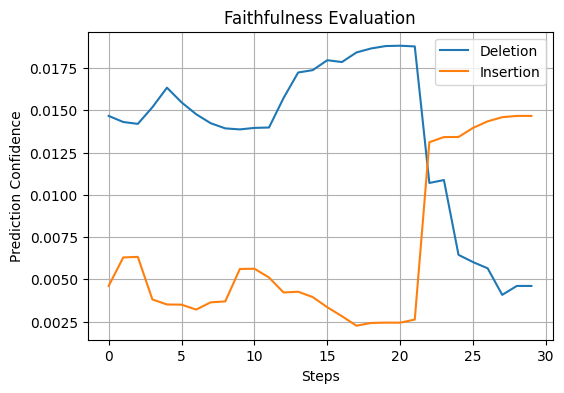

In [41]:
plt.figure(figsize=(6,4))

plt.plot(del_scores, label="Deletion")
plt.plot(insert_scores, label="Insertion")

plt.xlabel("Steps")
plt.ylabel("Prediction Confidence")

plt.title("Faithfulness Evaluation")

plt.legend()
plt.grid()

plt.show()

In [42]:
test_df = pd.read_csv("/kaggle/input/ecg-data/mitbih_test.csv", header=None)

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

X_test_ts = np.array([create_ts_channels(x) for x in X_test])

In [43]:
def add_noise(signal, noise_std):
    noise = np.random.normal(0, noise_std, signal.shape)
    return signal + noise

In [44]:
from sklearn.metrics import accuracy_score

def evaluate(model, X, y):
    y_pred = np.argmax(model.predict(X), axis=1)
    return accuracy_score(y, y_pred)

In [45]:
noise_levels = [0.01,0.02,0.05,0.1]
accs = []

for n in noise_levels:
    X_noise = np.array([add_noise(x,n) for x in X_test_ts])
    acc = evaluate(model,X_noise,y_test)
    accs.append(acc)

685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step


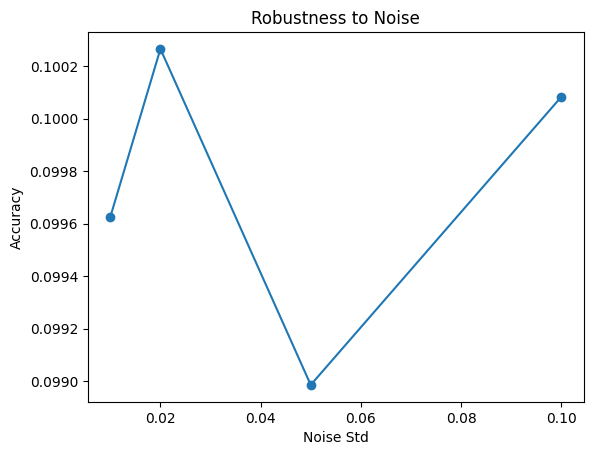

In [46]:
plt.plot(noise_levels, accs, marker='o')
plt.xlabel("Noise Std")
plt.ylabel("Accuracy")
plt.title("Robustness to Noise")
plt.show()

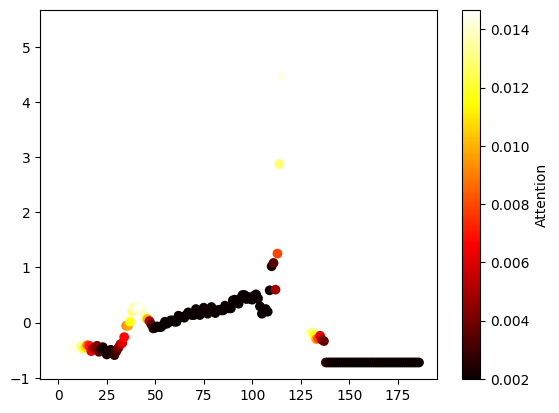

In [47]:
plt.scatter(
    np.arange(187),
    x_sample[0,:,0],
    c=attention,
    cmap="hot"
)
plt.colorbar(label="Attention")